<a href="https://colab.research.google.com/github/AnastasiaKovalenko232/iad-practices/blob/main/practice-6/6_2_EM_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EM Clustering

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.utils import shuffle

## Generate Data

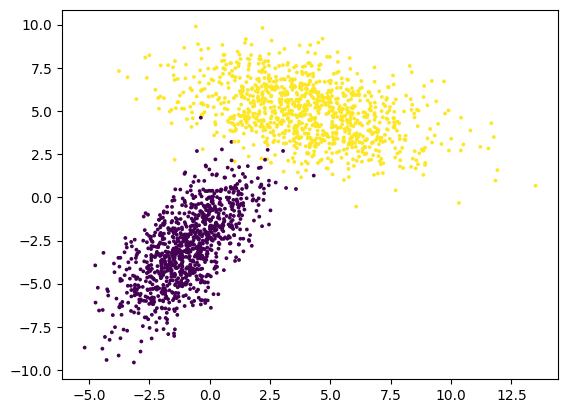

In [3]:
num_points = 1000

mean_1 = [-1, -3]
cov_1 = [[2, 2], [2, 5]]
x_1 = np.random.multivariate_normal(mean_1, cov_1, num_points)

mean_2 = [4, 5]
cov_2 = [[7, -2], [-2, 3]]
x_2 = np.random.multivariate_normal(mean_2, cov_2, num_points)

X = np.concatenate([x_1, x_2])
y = np.array([0] * num_points + [1] *  num_points)
X, y = shuffle(X, y, random_state=0)
plt.scatter(X[:, 0], X[:, 1], s = 3, c = y)

## Silhouette score

In [4]:
for i in range(2, 5):
    gmm = GaussianMixture(n_components=i, covariance_type='full')
    gmm_labels = gmm.fit_predict(X)
    silhouette_avg = silhouette_score(X, gmm_labels)
    print("For n_clusters =", i, " silhouette average:", silhouette_avg)

For n_clusters = 2  silhouette average: 0.6313606307734999
For n_clusters = 3  silhouette average: 0.47874755132546576
For n_clusters = 4  silhouette average: 0.48326319937075446


## Covariance type

In [5]:
GMM = GaussianMixture(n_components=2, covariance_type='full')
GMM.fit(X)
print('means ')
print(GMM.means_)
print('covariances ')
print(GMM.covariances_)

means 
[[-0.94655741 -2.92915567]
 [ 3.95423642  4.96348722]]
covariances 
[[[ 1.95279504  2.01648073]
  [ 2.01648073  4.80904069]]

 [[ 6.78474286 -1.7918652 ]
  [-1.7918652   2.81983655]]]


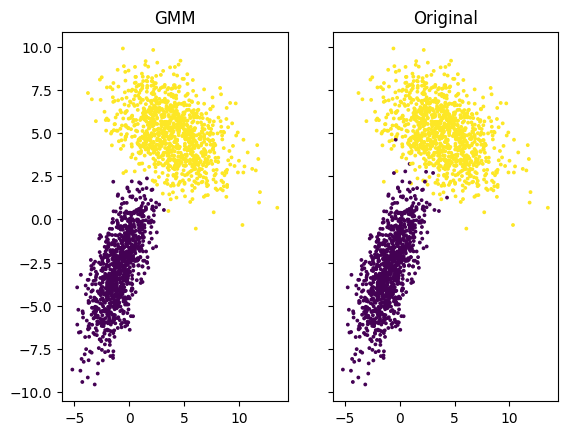

In [6]:
labels = GMM.predict(X)

f, (ax1, ax2) = plt.subplots(1, 2, sharey=True)
ax1.set_title('GMM')
ax1.scatter(X[:,0], X[:,1], c=labels, s=3)
ax2.set_title("Original")
ax2.scatter(X[:,0], X[:,1], c=y, s=3)

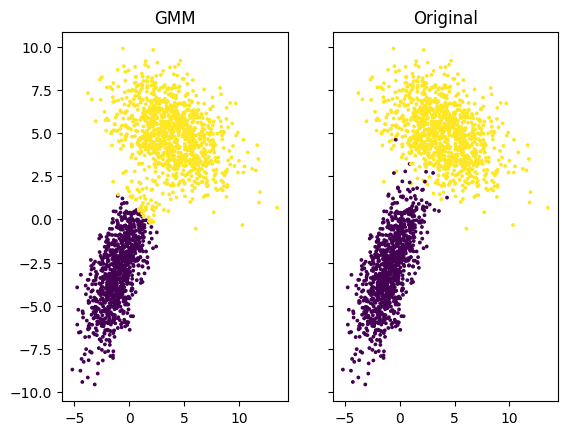

In [7]:
GMM = GaussianMixture(n_components=2, covariance_type='spherical')
GMM.fit(X)

labels = GMM.predict(X)

f, (ax1, ax2) = plt.subplots(1, 2, sharey=True)
ax1.set_title('GMM')
ax1.scatter(X[:,0], X[:,1], c=labels, s=3)
ax2.set_title("Original")
ax2.scatter(X[:,0], X[:,1], c=y, s=3)

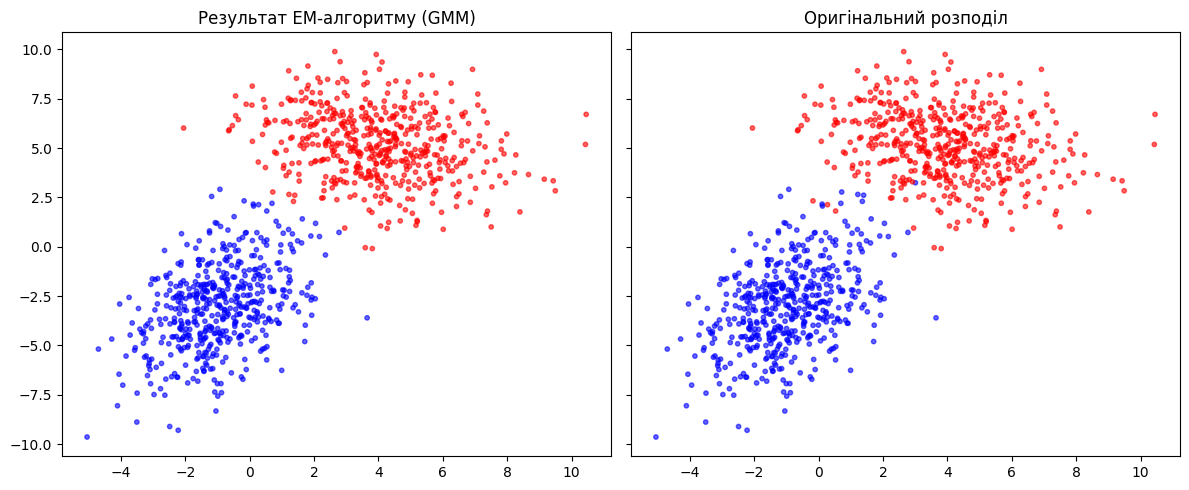

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# 1. Генерація складніших Гауссових розподілів з шумом
np.random.seed(42)
num_points = 500

mean_1 = [-1, -3]
cov_1 = [[2, 1.5], [1.5, 5]]
x_1 = np.random.multivariate_normal(mean_1, cov_1, num_points)

mean_2 = [4, 5]
cov_2 = [[4, -1], [-1, 3]]
x_2 = np.random.multivariate_normal(mean_2, cov_2, num_points)

# Об'єднуємо в один загальний датасет
X = np.vstack([x_1, x_2])
y_true = np.hstack([np.zeros(num_points), np.ones(num_points)])

# 2. Навчання моделі Gaussian Mixture (EM-алгоритм)
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm.fit(X)
labels = gmm.predict(X)

# 3. Візуалізація
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

ax1.set_title('Результат EM-алгоритму (GMM)')
ax1.scatter(X[:, 0], X[:, 1], c=labels, cmap='bwr', s=10, alpha=0.6)

ax2.set_title('Оригінальний розподіл')
ax2.scatter(X[:, 0], X[:, 1], c=y_true, cmap='bwr', s=10, alpha=0.6)

plt.tight_layout()
plt.show()